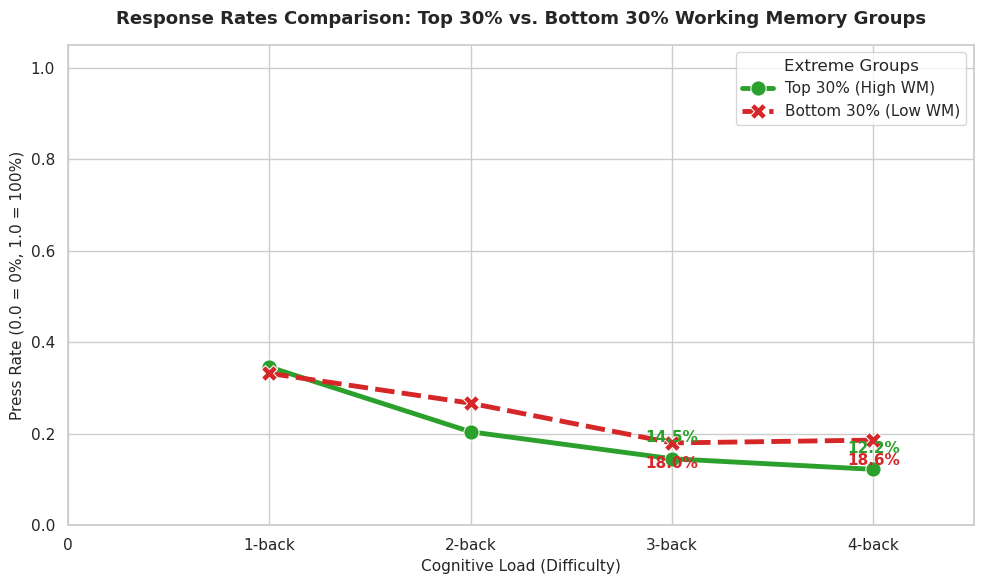

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_dir = "/mnt/c/Users/user/Documents/brainhack2026"
os.chdir(data_dir)

excluded_subjects = ["sub-013", "sub-017"]
all_data = []

search_path = os.path.join(data_dir, "sub-*", "eeg", "*_task-nback_events.tsv")
file_list = glob.glob(search_path)

for file_path in sorted(file_list):
    sub_str = os.path.basename(file_path).split('_')[0]
    if sub_str in excluded_subjects:
        continue
        
    try:
        df = pd.read_csv(file_path, sep='\t')
        df_valid = df[df['outcome'].isin(['Correct', 'Wrong'])].copy()
        if df_valid.empty:
            continue
            
        df_valid['nback_level'] = df_valid['nback_level'].astype(float).astype(int)
        
        def check_pressed(row):
            if (row['outcome'] == 'Correct' and row['matched'] == True) or \
               (row['outcome'] == 'Wrong' and row['matched'] == False):
                return 1
            return 0
        df_valid['is_pressed'] = df_valid.apply(check_pressed, axis=1)
        
        for load in [1, 2, 3, 4]:
            df_load = df_valid[df_valid['nback_level'] == load]
            if len(df_load) > 0:
                acc = (df_load['outcome'] == 'Correct').sum() / len(df_load)
                press_rate = df_load['is_pressed'].sum() / len(df_load)
                
                all_data.append({
                    'Subject': sub_str,
                    'N-back Level': load,
                    'N-back': f"{load}-back",
                    'Accuracy': acc,
                    'Press Rate': press_rate
                })
    except Exception:
        pass

df_master = pd.DataFrame(all_data)
df_2back = df_master[df_master['N-back Level'] == 2][['Subject', 'Accuracy']].copy()

cutoff_high = df_2back['Accuracy'].quantile(0.70)
cutoff_low = df_2back['Accuracy'].quantile(0.30)

def assign_extreme_group(acc):
    if acc >= cutoff_high:
        return 'Top 30% (High WM)'
    elif acc <= cutoff_low:
        return 'Bottom 30% (Low WM)'
    else:
        return 'Middle 40% (Excluded)'

df_2back['Group'] = df_2back['Accuracy'].apply(assign_extreme_group)

group_mapping = dict(zip(df_2back['Subject'], df_2back['Group']))
df_master['Group'] = df_master['Subject'].map(group_mapping)

df_extreme = df_master[df_master['Group'] != 'Middle 40% (Excluded)'].copy()

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

df_group_avg = df_extreme.groupby(['Group', 'N-back Level', 'N-back'])['Press Rate'].mean().reset_index()
df_group_avg['Group'] = pd.Categorical(df_group_avg['Group'], categories=['Top 30% (High WM)', 'Bottom 30% (Low WM)'], ordered=True)
df_group_avg = df_group_avg.sort_values('Group')

ax = sns.lineplot(
    data=df_group_avg,
    x='N-back Level',
    y='Press Rate',
    hue='Group',
    style='Group',
    markers=True,
    markersize=11,
    linewidth=3.5,
    palette=['#2ca02c', '#d62728']
)

for group in df_group_avg['Group'].unique():
    df_sub = df_group_avg[df_group_avg['Group'] == group]
    color = '#2ca02c' if 'Top 30%' in group else '#d62728'
    for idx, row in df_sub.iterrows():
        if row['N-back Level'] in [3, 4]:
            plt.annotate(
                f"{row['Press Rate']*100:.1f}%",
                (row['N-back Level'], row['Press Rate']),
                textcoords="offset points",
                xytext=(0, 12 if 'Top 30%' in group else -18),
                ha='center', fontsize=11, fontweight='bold', color=color
            )

plt.xlim(0, 4.5)
plt.ylim(0, 1.05)
plt.xticks([0, 1, 2, 3, 4], ['0', '1-back', '2-back', '3-back', '4-back'])

plt.title("Response Rates Comparison: Top 30% vs. Bottom 30% Working Memory Groups", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Cognitive Load (Difficulty)", fontsize=11)
plt.ylabel("Press Rate (0.0 = 0%, 1.0 = 100%)", fontsize=11)
plt.legend(title="Extreme Groups", loc="upper right")

plt.tight_layout()
plt.savefig('extreme_groups_press_rate_trend.png', dpi=300, bbox_inches='tight')
plt.show()

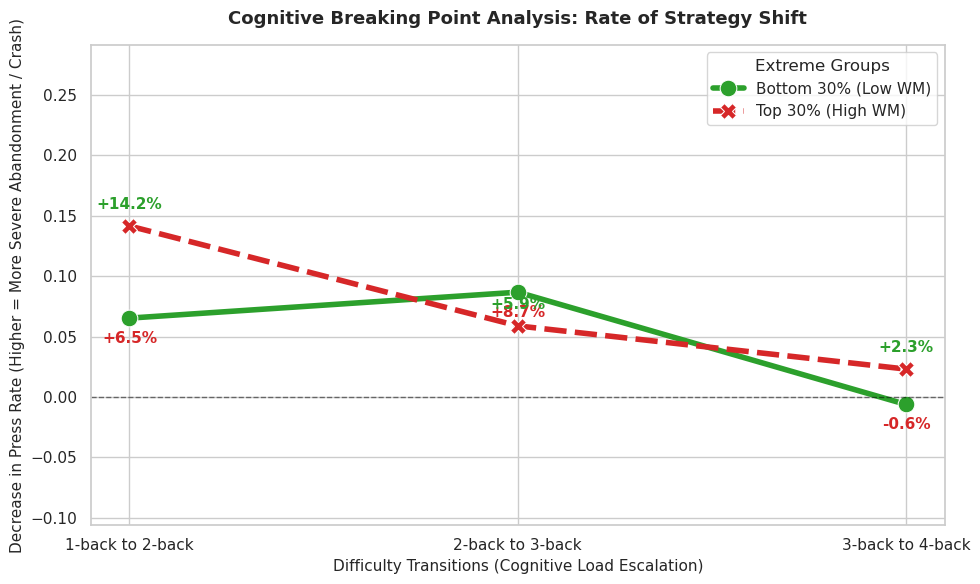

In [2]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_dir = "/mnt/c/Users/user/Documents/brainhack2026"
os.chdir(data_dir)

excluded_subjects = ["sub-013", "sub-017"]
all_slopes = []

search_path = os.path.join(data_dir, "sub-*", "eeg", "*_task-nback_events.tsv")
file_list = glob.glob(search_path)

for file_path in sorted(file_list):
    sub_str = os.path.basename(file_path).split('_')[0]
    if sub_str in excluded_subjects:
        continue
        
    try:
        df = pd.read_csv(file_path, sep='\t')
        df_valid = df[df['outcome'].isin(['Correct', 'Wrong'])].copy()
        if df_valid.empty:
            continue
            
        df_valid['nback_level'] = df_valid['nback_level'].astype(float).astype(int)
        
        def check_pressed(row):
            if (row['outcome'] == 'Correct' and row['matched'] == True) or \
               (row['outcome'] == 'Wrong' and row['matched'] == False):
                return 1
            return 0
        df_valid['is_pressed'] = df_valid.apply(check_pressed, axis=1)
        
        press_rates = {}
        for load in [1, 2, 3, 4]:
            df_load = df_valid[df_valid['nback_level'] == load]
            if len(df_load) > 0:
                press_rates[load] = df_load['is_pressed'].sum() / len(df_load)
        
        if all(k in press_rates for k in [1, 2, 3, 4]):
            all_slopes.append({'Subject': sub_str, 'Transition': '1-back to 2-back', 'Drop Amount': press_rates[1] - press_rates[2]})
            all_slopes.append({'Subject': sub_str, 'Transition': '2-back to 3-back', 'Drop Amount': press_rates[2] - press_rates[3]})
            all_slopes.append({'Subject': sub_str, 'Transition': '3-back to 4-back', 'Drop Amount': press_rates[3] - press_rates[4]})
            
    except Exception:
        pass

df_slopes_master = pd.DataFrame(all_slopes)
df_slopes_master['Group'] = df_slopes_master['Subject'].map(group_mapping)

df_slopes_extreme = df_slopes_master[df_slopes_master['Group'] != 'Middle 40% (Excluded)'].copy()

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

df_slope_avg = df_slopes_extreme.groupby(['Group', 'Transition'])['Drop Amount'].mean().reset_index()

df_slope_avg['Transition'] = pd.Categorical(
    df_slope_avg['Transition'], 
    categories=['1-back to 2-back', '2-back to 3-back', '3-back to 4-back'], 
    ordered=True
)
df_slope_avg = df_slope_avg.sort_values(['Group', 'Transition'])

ax = sns.lineplot(
    data=df_slope_avg,
    x='Transition',
    y='Drop Amount',
    hue='Group',
    style='Group',
    markers=True,
    markersize=12,
    linewidth=4,
    palette=['#2ca02c', '#d62728']
)

for idx, row in df_slope_avg.iterrows():
    color = '#2ca02c' if 'Top 30%' in row['Group'] else '#d62728'
    x_coord = ['1-back to 2-back', '2-back to 3-back', '3-back to 4-back'].index(row['Transition'])
    plt.annotate(
        f"{row['Drop Amount']*100:+.1f}%",
        (x_coord, row['Drop Amount']),
        textcoords="offset points",
        xytext=(0, 12 if 'Top 30%' in row['Group'] else -18),
        ha='center', fontsize=11, fontweight='bold', color=color
    )

plt.title("Cognitive Breaking Point Analysis: Rate of Strategy Shift", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Difficulty Transitions (Cognitive Load Escalation)", fontsize=11)
plt.ylabel("Decrease in Press Rate (Higher = More Severe Abandonment / Crash)", fontsize=11)
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.ylim(df_slope_avg['Drop Amount'].min() - 0.1, df_slope_avg['Drop Amount'].max() + 0.15)
plt.legend(title="Extreme Groups", loc="upper right")

plt.tight_layout()
plt.savefig('breaking_point_trend_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

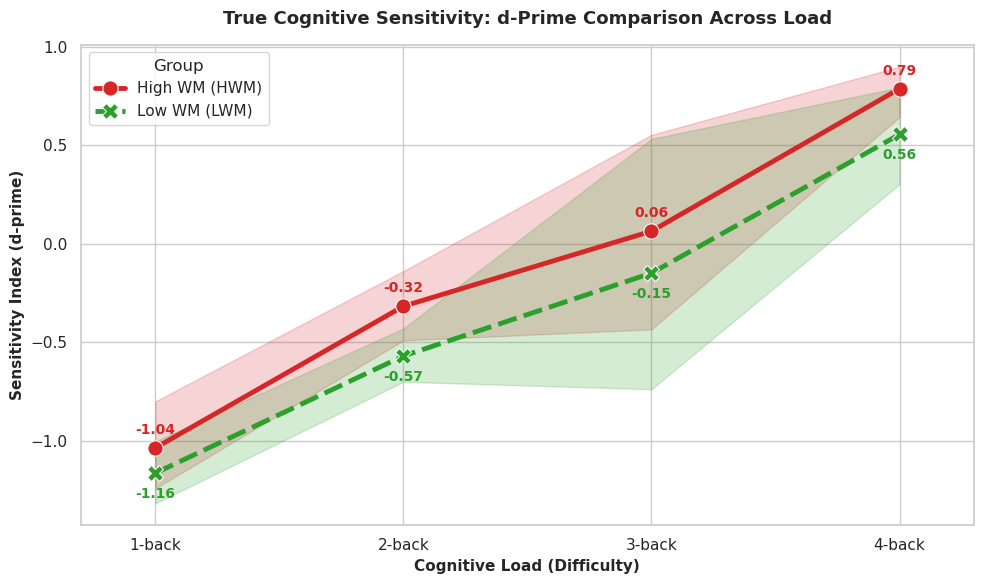

In [3]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

data_dir = "/mnt/c/Users/user/Documents/brainhack2026"
os.chdir(data_dir)
excluded_subjects = ["sub-013", "sub-017"]
dprime_data = []

search_path = os.path.join(data_dir, "sub-*", "eeg", "*_task-nback_events.tsv")
for file_path in sorted(glob.glob(search_path)):
    sub_str = os.path.basename(file_path).split('_')[0]
    if sub_str in excluded_subjects: 
        continue
    try:
        df = pd.read_csv(file_path, sep='\t')
        df_valid = df[df['outcome'].isin(['Correct', 'Wrong'])].copy()
        if df_valid.empty: 
            continue
        df_valid['nback_level'] = df_valid['nback_level'].astype(float).astype(int)
        
        for load in [1, 2, 3, 4]:
            df_load = df_valid[df_valid['nback_level'] == load]
            if len(df_load) > 0:
                targets = df_load[df_load['matched'] == True]
                nontargets = df_load[df_load['matched'] == False]
                
                hits = (targets['outcome'] == 'Correct').sum()
                fas = (nontargets['outcome'] == 'Wrong').sum()
                
                n_targets = len(targets)
                n_nontargets = len(nontargets)
                
                hit_rate_adj = (hits + 0.5) / (n_targets + 1) if n_targets > 0 else 0.5
                fa_rate_adj = (fas + 0.5) / (n_nontargets + 1) if n_nontargets > 0 else 0.5
                
                d_prime = norm.ppf(hit_rate_adj) - norm.ppf(fa_rate_adj)
                
                dprime_data.append({
                    'Subject': sub_str, 'N-back Level': load, 'N-back': f"{load}-back",
                    'd-prime': d_prime
                })
    except Exception: 
        pass

df_dp = pd.DataFrame(dprime_data)

df_dp['Group'] = df_dp['Subject'].map(group_mapping)
df_dp_extreme = df_dp[df_dp['Group'] != 'Middle 40% (Excluded)'].copy()
df_dp_extreme['Group'] = df_dp_extreme['Group'].replace({
    'Top 30% (High WM)': 'High WM (HWM)',
    'Bottom 30% (Low WM)': 'Low WM (LWM)'
})

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.lineplot(
    data=df_dp_extreme,
    x='N-back Level',
    y='d-prime',
    hue='Group',
    style='Group',
    markers=True, markersize=11, linewidth=3.5,
    palette={'High WM (HWM)': '#d62728', 'Low WM (LWM)': '#2ca02c'}
)

df_dp_avg = df_dp_extreme.groupby(['Group', 'N-back Level'])['d-prime'].mean().reset_index()
for idx, row in df_dp_avg.iterrows():
    color = '#d62728' if 'High WM' in row['Group'] else '#2ca02c'
    plt.annotate(
        f"{row['d-prime']:.2f}",
        (row['N-back Level'], row['d-prime']),
        textcoords="offset points",
        xytext=(0, 10 if 'High WM' in row['Group'] else -18),
        ha='center', fontsize=10, fontweight='bold', color=color
    )

plt.title("True Cognitive Sensitivity: d-Prime Comparison Across Load", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Cognitive Load (Difficulty)", fontsize=11, fontweight='bold')
plt.ylabel("Sensitivity Index (d-prime)", fontsize=11, fontweight='bold')
plt.xticks([1, 2, 3, 4], ['1-back', '2-back', '3-back', '4-back'])
plt.xlim(0.7, 4.3)

plt.tight_layout()
plt.savefig('dprime_trend_comparison.png', dpi=300)
plt.show()